7-1강

# CNN

https://youtu.be/D7FhUXdZ2Kg?si=OaXJ4QRD4589xKYl


## CNN 복습

- 실제 **뇌**가 이미지를 인식할 때 뇌의 일부분만 활성화됨.

  - 과연 첫 layer에서 부터 모든 픽셀을 보는게 좋을까? <- 아님

  - 뇌는 생각보다 대충봄. 눈은 화질이 매우 좋지만, 전체 이미지의 전체에서 극히 일부분에만 집중하고, 나머지 요소들도 특징으로 큼직 큼직하게 인식하지, 세세하게 인식하지 않음.

  - 그렇기에 적어도 이미지 인식 초반에서는 MLP를 쓰는 것은 매우 비효율적.

- 그래서 위치별 특징을 추출하고, 위치 정보를 유지한채로 패턴을 찾음.
  - 정확히는 이미지가 있을때, 각 노드 그룹별로 보는 이미지의 부분이 다른겨.
  - 그 위치에 대한 정보를 인지하고 있다는 것만으로 시각 정보 수집에 매우 유리해짐.

- Fully Conncected Layer, 즉 MLP만 쓰면.. 이미지를 섞어서 학습해도 성능이 똑같이 나올 듯? 애초에 위치 정보를 고려하지 않으니.
  - 실험을 봤는데, cifar10을 학습한 MLP에 원본을 보고 맞췄을 때랑, 이미지를 왕창 섞고 다시 학습한거랑 성공률이 45퍼로 비슷하게 나옴.
  - 즉, MLP는 **상대적인 위치**를 **고려하지 않음**. 물론 **절대적인 위치**는 고려하긴함.

- bias도 있음. 커널당 하나임.

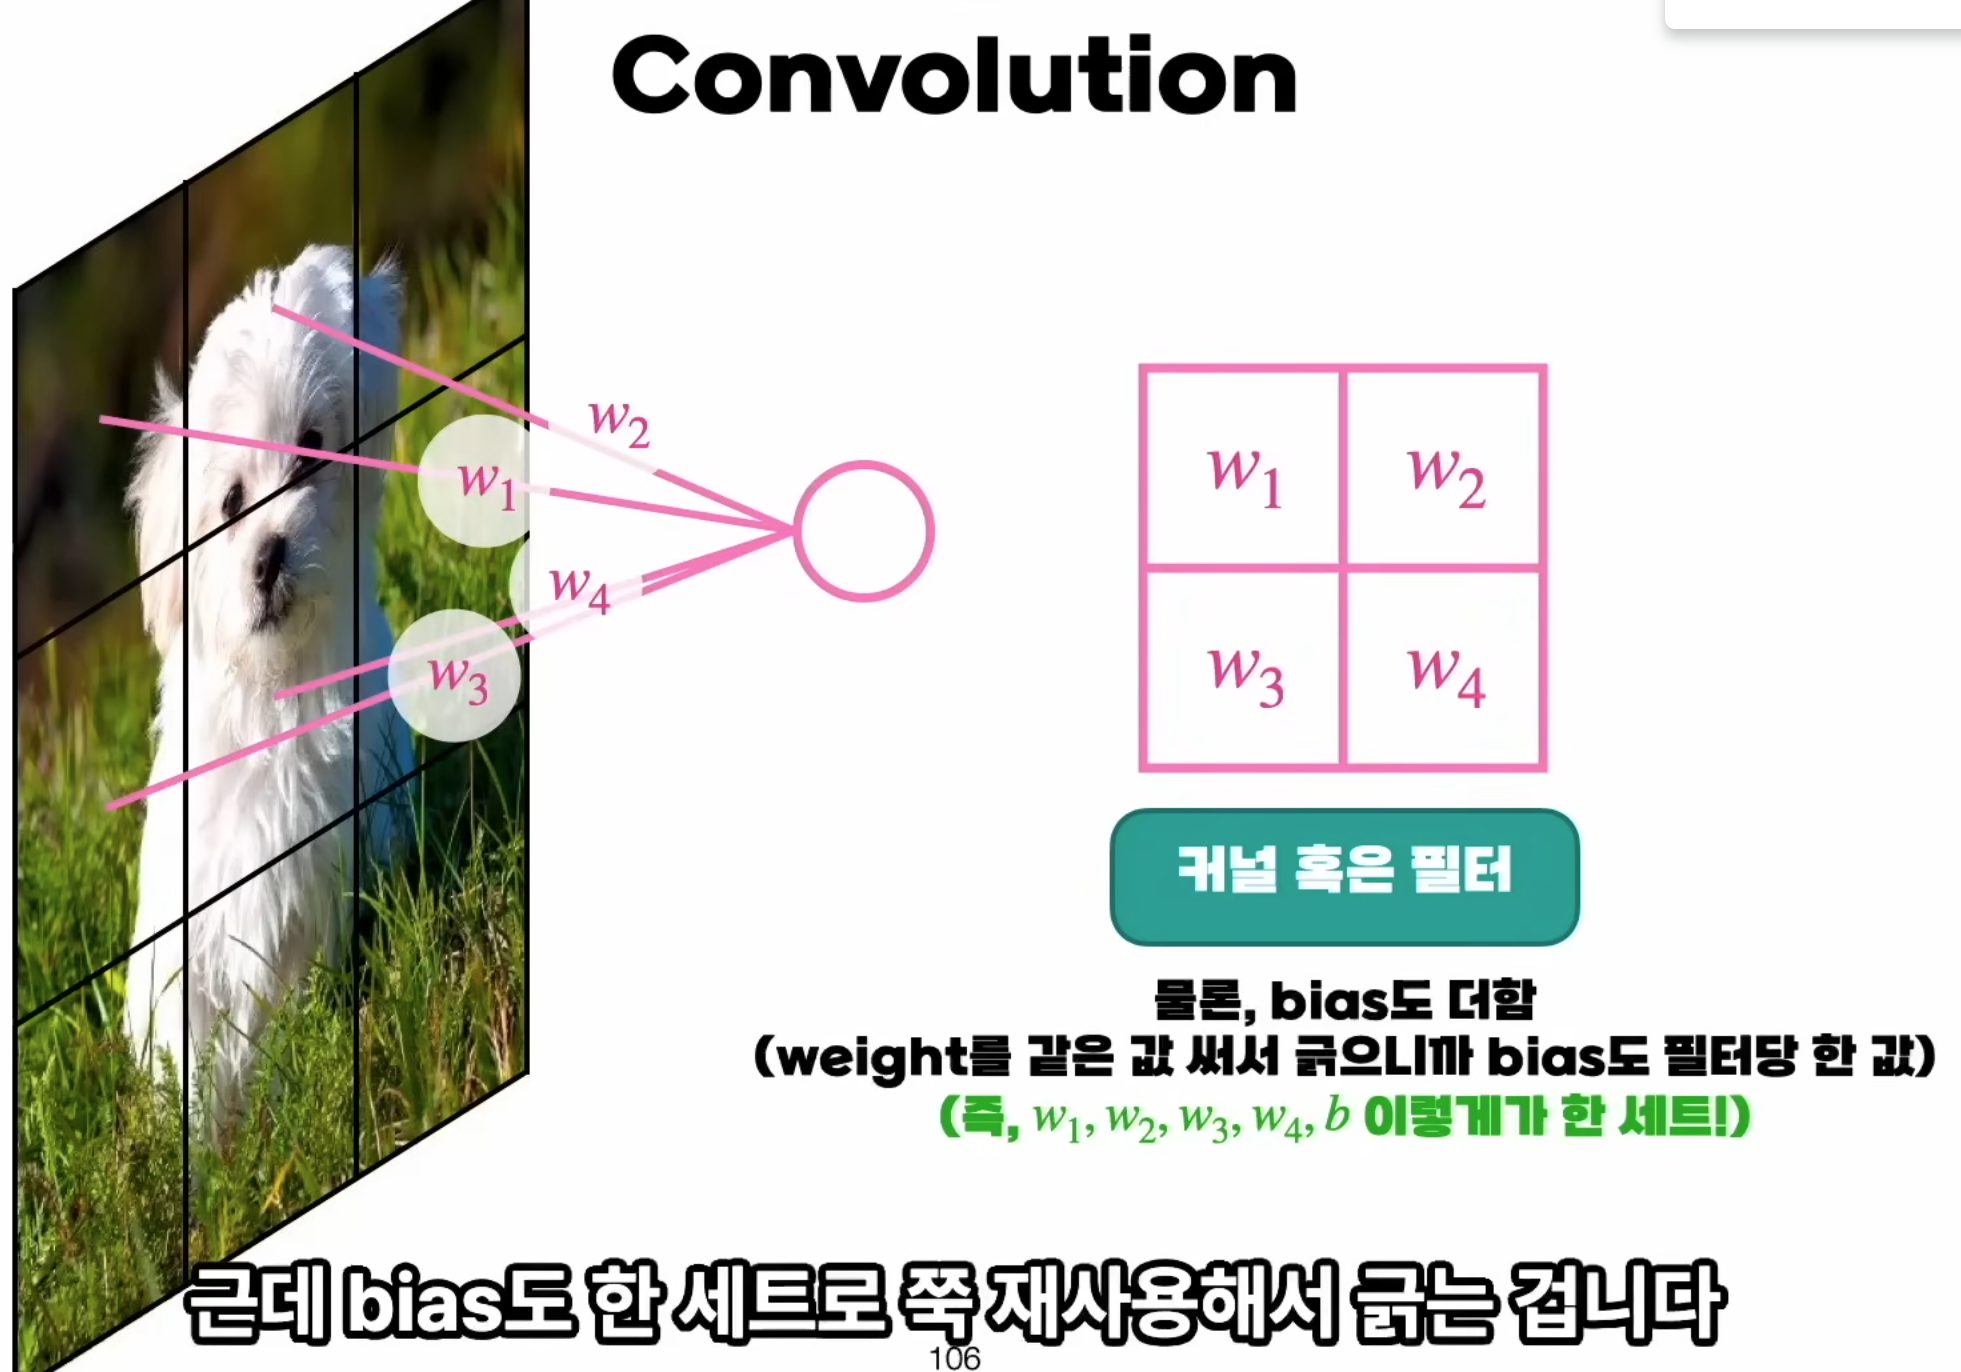

- 이 커널, 즉 필터를 학습하는 과정은 곧 실제 컴퓨터 비전에서 사용하는 필터들을 각각 학습해서 만드는 것과 비슷한거임.

- RGB에 커널 세트를 하나 합성곱하고나면, 결국 이를 다 더해서 **피쳐맵을 하나만** 만들지만.

  - 한 데이터에 개별적으로 서로 다른 커널 세트들을 여러번 곱하는 것은 피쳐맵의 depth를 키우는 것이다.


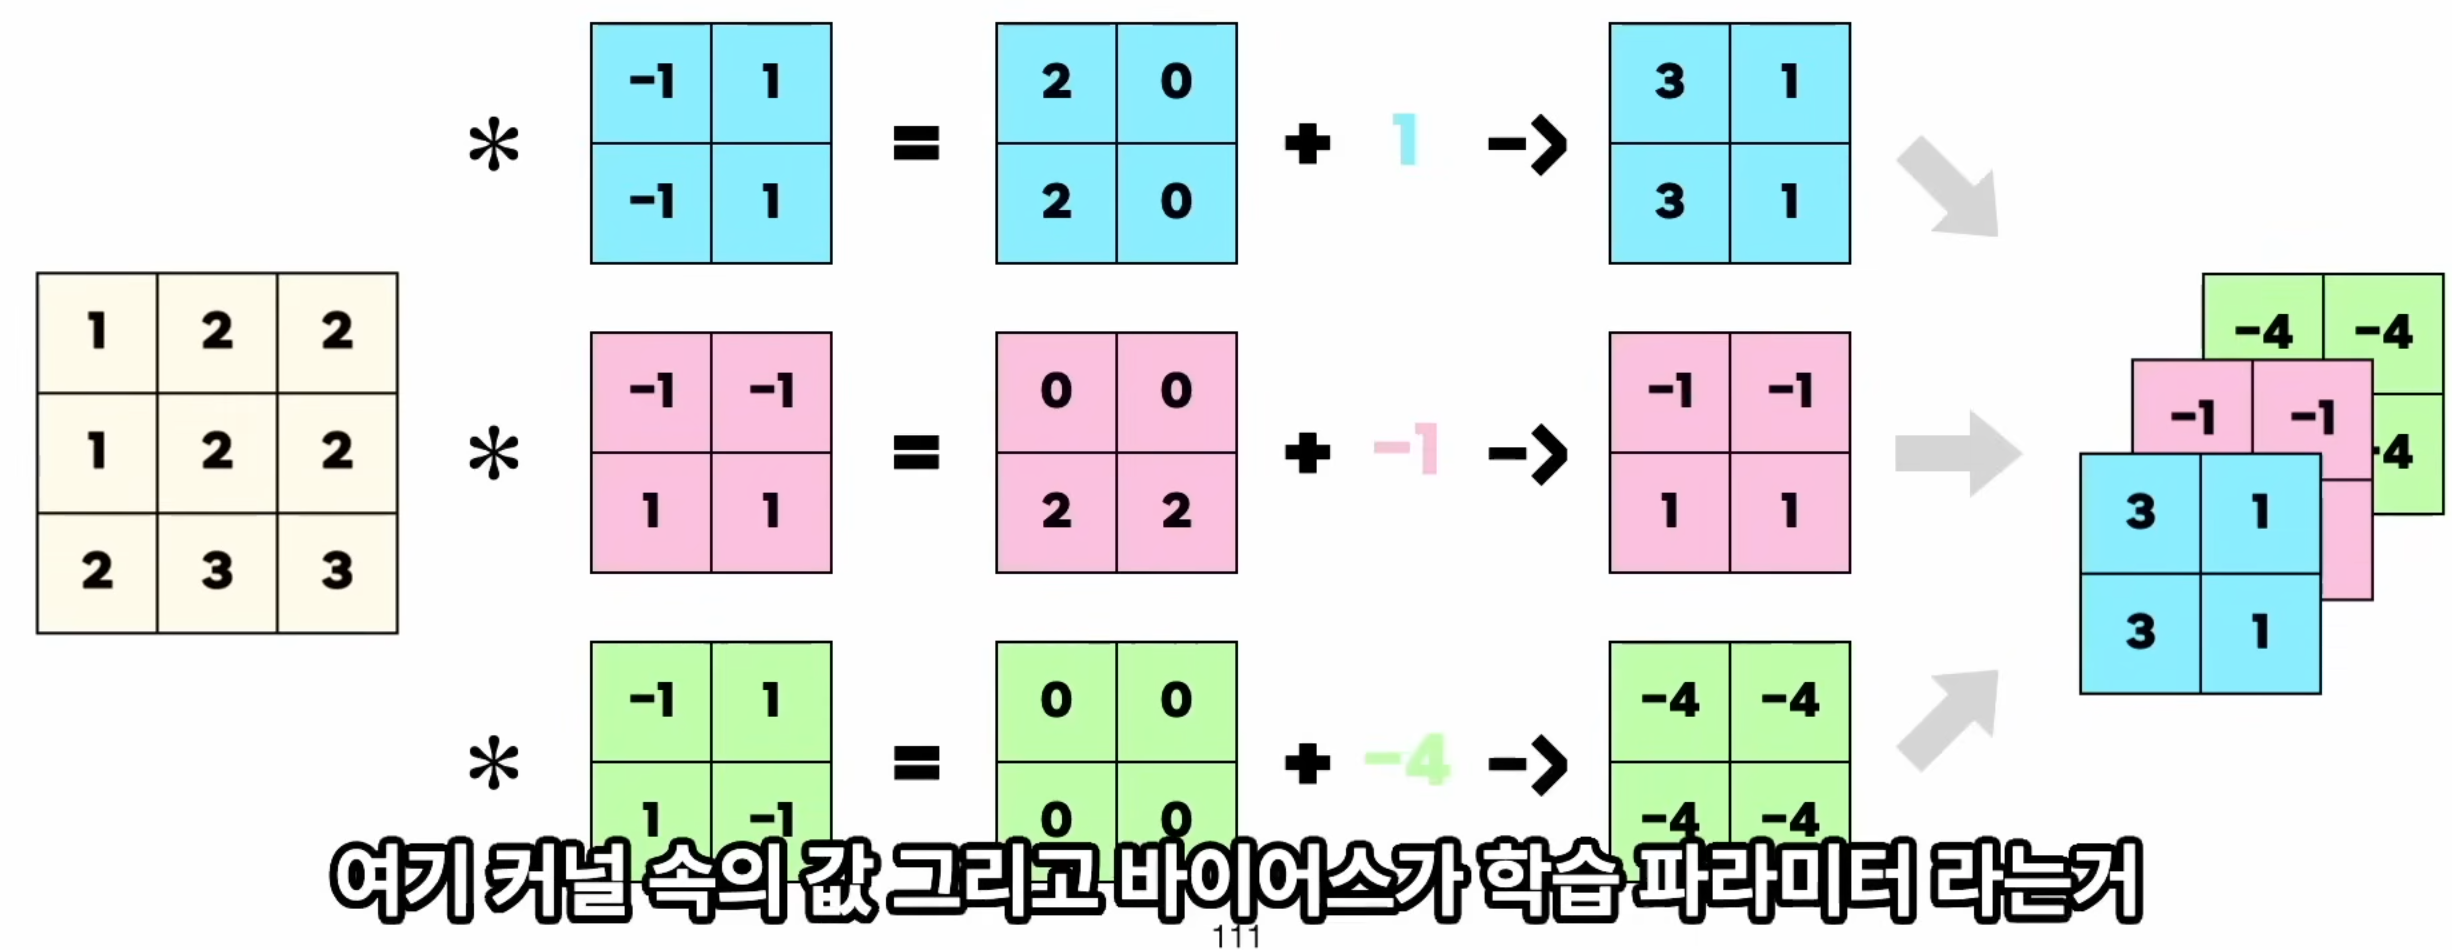

- 참고로 RGB 이미지에 커널 세트를 곱할 때, 이는 **커널 3개**를 가진 **필터 하나**를 곱하는 것이라고 한다.

- 그러니 **두개의 필터**를 쓰면, **두개의 피쳐맵**을 얻는거고.
  - 그리고 각 필터 속의 **커널 개수**는 **이전 층의 depth**와 같다.

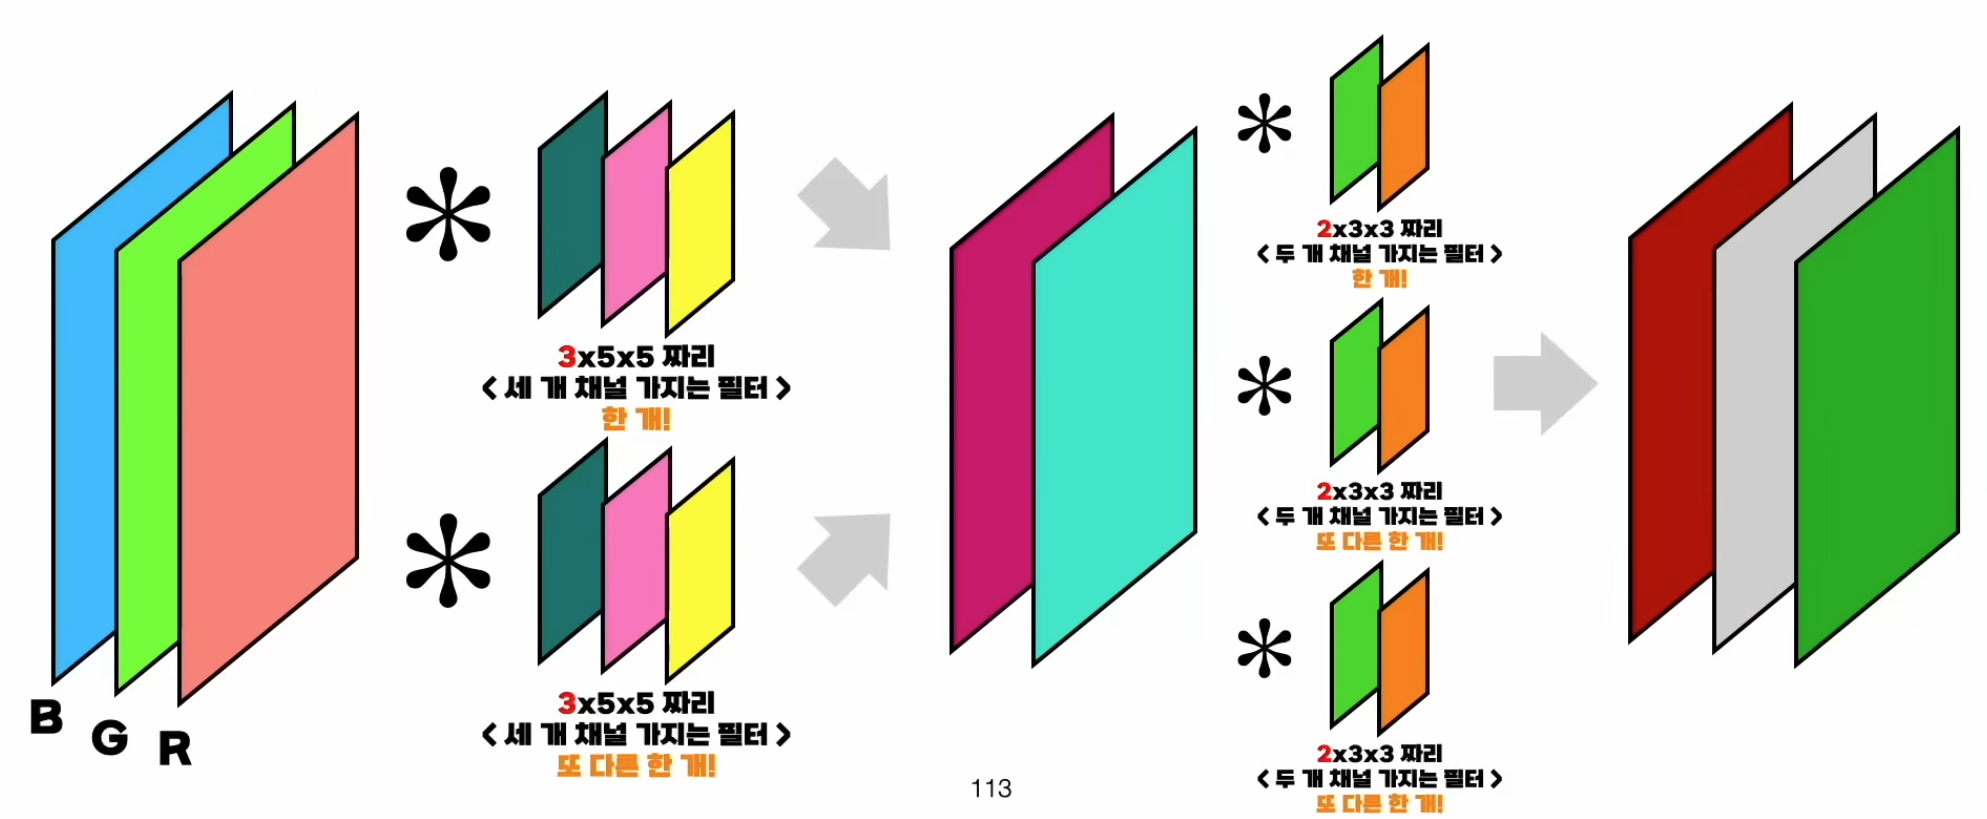

- Pooling 중에서 피쳐맵의 전체를 보는 Pooling은 보통 평균 풀링을 많이 사용하고, 그 명칭은 GLobal Average Pooling, **GAP**이다. 자주 나오니 익숙해져라.

## 다시 코드로

In [ ]:
import torch
from torch import nn

In [ ]:

# Conv에는 반드시 적어도 3개의 정보를 줘야함.
# 인풋 채널 수 (RGB면 3, 흑백은 1), 아웃풋 채널 수 (피쳐맵, 즉 필터수이기도 함), 그리고 커널이 보는 영역의 크기
layer = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3) # stride=1, padding=0 이 디폴트

# 32개의 데이터, 흑백이라 1, 그리고 그 이미지의 크기는 5x5
layer(torch.randn(32,1,5,5)).shape # 통과하고 나면 [32, 2, 3, 3]

# 여기서 Linear와 Conv2d 인풋 구조의 차이를 볼 수 있음. 그냥 뒤 부분만 달라짐.
# nn.Linear(3,5) # 채채 # 근데 얘는 채 또는 개채를 원함, 개x3 => 개x5
# nn.Conv2d(3,5) # 채채 # 근데 얘는 채행열 또는 개채행열을 원함, 개x3x행x열 => 개x5x행x열

torch.Size([32, 2, 3, 3])

In [ ]:
# 키워드 안쓰고 그냥 적었음.
# RGB 3, 아웃풋 피쳐맵 5개, 커널 사이즈 3개
layer = nn.Conv2d(3,5,3) # 이 경우 weight(=필터=커널)가 3x3x3 짜리 5개 존재 (5x3x3x3)
print(layer(torch.randn(32,3,5,5)).shape)
print(layer.weight.shape) # 5x3x3x3

torch.Size([32, 5, 3, 3])
torch.Size([5, 3, 3, 3])


- 더 깊게

In [ ]:
conv1 = nn.Conv2d(1,8,6, stride=2)
x=torch.randn(32,1,28,28)
print(conv1(x).shape)

conv2 = nn.Conv2d(8,16,3,padding=1) # 위 아웃풋 피쳐맵이 8개니 여기 인풋은 8임
print(conv2(conv1(x)).shape)

Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
print(Maxpool(conv2(conv1(x))).shape)

torch.Size([32, 8, 12, 12])
torch.Size([32, 16, 12, 12])
torch.Size([32, 16, 6, 6])


- Pooling

이건 채널의 개수가 바뀌지는 않음. 각 피쳐맵의 크기가 작아질 뿐.

In [ ]:
maxpool=nn.MaxPool2d(2) # 2 로만 줘도 자동 kernel_size=2, stride=2
x=torch.randn(1,6,6)
print(x)
print(maxpool(x))
print(maxpool(torch.randn(32,3,6,6)).shape) # 절반이 됐당!

tensor([[[ 1.4508,  1.2351, -0.1721, -0.8050,  0.8960,  1.4790],
         [ 1.2025,  0.2959,  0.9014,  1.3928, -0.0992,  0.1652],
         [-0.4537, -0.6552,  0.2149,  1.6889,  3.0299, -0.0410],
         [ 0.9186, -0.7073, -0.3975, -0.7102,  0.1082, -1.7873],
         [ 0.0921, -0.7804,  1.0844,  0.0098,  2.5335,  0.0434],
         [-0.2312, -0.5420,  0.3061, -0.5004, -0.6212,  1.6690]]])
tensor([[[1.4508, 1.3928, 1.4790],
         [0.9186, 1.6889, 3.0299],
         [0.0921, 1.0844, 2.5335]]])
torch.Size([32, 3, 3, 3])


In [ ]:
maxpool=nn.AvgPool2d(2)
x=torch.randn(1,6,6)
print(x)
print(maxpool(x))
print(maxpool(torch.randn(32,3,6,6)).shape)

tensor([[[-1.6744, -0.1683, -1.8907, -0.3108, -0.1929,  1.6715],
         [ 0.6502,  1.1636, -0.3664, -0.3209, -2.0842,  0.5301],
         [-1.4997, -0.1256, -0.0465, -1.4714, -0.1910, -0.6833],
         [ 0.5297,  0.9584,  0.7476,  0.0360,  0.5178,  0.0673],
         [ 0.6116, -0.0069, -0.9926,  0.1999, -1.1193,  0.6407],
         [-1.0735, -1.1969,  1.3769, -0.7167, -0.1067,  0.0876]]])
tensor([[[-0.0073, -0.7222, -0.0189],
         [-0.0343, -0.1836, -0.0723],
         [-0.4164, -0.0331, -0.1244]]])
torch.Size([32, 3, 3, 3])


- 위를 잘 조합하면 CNN이 됨

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # 위에서 했던 conv랑 pool으로 CNN 만들기. 이것도 매우 easy함. +
        self.conv1 = nn.Conv2d(1,8,6, stride=2)
        self.conv2 = nn.Conv2d(8,16,3, padding=1)
        self.Maxpool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16*6*6,10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.Maxpool(x)

        # 하지만 위의 아웃풋으로는 MLP를 통과시킬 수 없음! ++
        x = torch.flatten(x, start_dim=1) # 그래서 평탄화 필요! +
        x = self.fc(x)
        return x

x = torch.randn(32,1,28,28)
model = CNN()
print(model)
print(model(x).shape)

CNN(
  (conv1): Conv2d(1, 8, kernel_size=(6, 6), stride=(2, 2))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (Maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=576, out_features=10, bias=True)
)
torch.Size([32, 10])


- 위에는 넣지 않았지만, Conv사이에도 활성화 함수 ReLU를 넣는게 좋음. 그래야 학습이 잘 됨.

  - 실제 실무에서는 Conv $\rightarrow$ ReLU $\rightarrow$ Pool 구조로 많이 함.  